In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import shutil

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.utils import make_grid

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


In [3]:
BASE_PATH = '/content/drive/MyDrive/dataset'

def fix_folder_names(base):
    for split in ['train', 'val', 'test']:
        split_path = os.path.join(base, split)
        if not os.path.exists(split_path):
            continue
        for folder in os.listdir(split_path):
            old_path = os.path.join(split_path, folder)
            if not os.path.isdir(old_path):
                continue
            # spaces ko underscore, sab lowercase
            new_name = folder.lower().replace(' ', '_')
            new_path = os.path.join(split_path, new_name)
            if old_path != new_path:
                os.rename(old_path, new_path)
                print(f'Renamed: {folder} -> {new_name}')
            else:
                print(f'OK: {folder}')

fix_folder_names(BASE_PATH)
print('\nFolder names fixed!')

Renamed: Ishaq Dar -> ishaq_dar
Renamed: Chaudhary Nisar -> chaudhary_nisar
Renamed: Maryam Nawaz -> maryam_nawaz
Renamed: Assad Umar -> assad_umar
Renamed: Aitzaz Ahsan -> aitzaz_ahsan
Renamed: Maulana Fazl-ur-Rehman -> maulana_fazl-ur-rehman
Renamed: Shahbaz Sharif -> shahbaz_sharif
Renamed: Ahmed Sharif Chaudhary -> ahmed_sharif_chaudhary
Renamed: Bilawal Bhutto Zardari -> bilawal_bhutto_zardari
Renamed: Shah Mehmood Quereshi -> shah_mehmood_quereshi
Renamed: Khurshid Shah -> khurshid_shah
OK: asif_ali_zardari
OK: imran_khan
Renamed: Nawaz Sharif -> nawaz_sharif
Renamed: Rana Sanaullah -> rana_sanaullah
Renamed: Chaudhary Pervaiz Elahi -> chaudhary_pervaiz_elahi
Renamed: Shahbaz Sharif -> shahbaz_sharif
Renamed: Maulana Fazl-ur-Rehman -> maulana_fazl-ur-rehman
Renamed: Chaudhary Nisar -> chaudhary_nisar
Renamed: Ahmed Sharif Chaudhary -> ahmed_sharif_chaudhary
OK: asif_ali_zardari
Renamed: Maryam Nawaz -> maryam_nawaz
Renamed: Assad Umar -> assad_umar
Renamed: Shah Mehmood Quereshi 

In [4]:
TRAIN_DIR = os.path.join(BASE_PATH, 'train')
VAL_DIR   = os.path.join(BASE_PATH, 'val')
TEST_DIR  = os.path.join(BASE_PATH, 'test')

print(f'{"Split":8s} | {"Classes":>8} | {"Images":>8}')
print('-' * 30)
for split, d in [('train', TRAIN_DIR), ('val', VAL_DIR), ('test', TEST_DIR)]:
    count   = sum([len(files) for _, _, files in os.walk(d)])
    classes = len([f for f in os.listdir(d) if os.path.isdir(os.path.join(d, f))])
    print(f'{split:8s} | {classes:>8} | {count:>8}')

print('\nClass names:')
for c in sorted(os.listdir(TRAIN_DIR)):
    n = len(os.listdir(os.path.join(TRAIN_DIR, c)))
    print(f'  {c:35s} {n} images')

Split    |  Classes |   Images
------------------------------
train    |       16 |      993
val      |       16 |      200
test     |       16 |      138

Class names:
  ahmed_sharif_chaudhary              60 images
  aitzaz_ahsan                        60 images
  asif_ali_zardari                    64 images
  assad_umar                          60 images
  bilawal_bhutto_zardari              60 images
  chaudhary_nisar                     60 images
  chaudhary_pervaiz_elahi             60 images
  imran_khan                          79 images
  ishaq_dar                           60 images
  khurshid_shah                       60 images
  maryam_nawaz                        64 images
  maulana_fazl-ur-rehman              60 images
  nawaz_sharif                        63 images
  rana_sanaullah                      60 images
  shah_mehmood_quereshi               60 images
  shahbaz_sharif                      63 images


In [15]:
IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_EPOCHS  = 40
NUM_CLASSES = 16

# Train augmentation
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0)),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Val/Test — sirf resize + normalize
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset   = datasets.ImageFolder(VAL_DIR,   transform=val_test_transform)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

class_names = train_dataset.classes
NUM_CLASSES = len(class_names)
print(f'Total classes: {NUM_CLASSES}')
print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')

Total classes: 16
Train: 993 | Val: 200 | Test: 138


## Step 6 — Sample Images Dekho

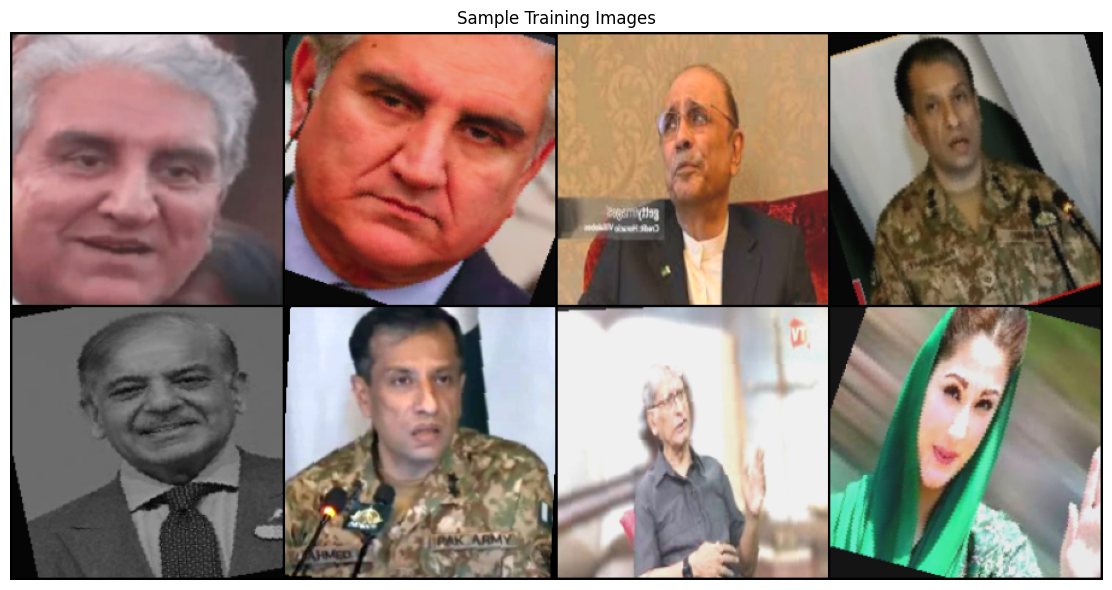

Labels: ['shah_mehmood_quereshi', 'shah_mehmood_quereshi', 'asif_ali_zardari', 'ahmed_sharif_chaudhary', 'shahbaz_sharif', 'ahmed_sharif_chaudhary', 'aitzaz_ahsan', 'maryam_nawaz']


In [16]:
def imshow_grid(loader, class_names, n=8):
    images, labels = next(iter(loader))
    images = images[:n]
    labels = labels[:n]
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    images = torch.clamp(images * std + mean, 0, 1)
    grid = make_grid(images, nrow=4)
    plt.figure(figsize=(14, 6))
    plt.imshow(grid.permute(1, 2, 0))
    plt.title('Sample Training Images')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    print('Labels:', [class_names[l] for l in labels.tolist()])

imshow_grid(train_loader, class_names)

## Step 7 — Model Definitions

In [17]:
def train_model(model, model_name, train_loader, val_loader,
                num_epochs=NUM_EPOCHS, lr=0.001):

    model     = model.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs, eta_min=1e-6
    )

    history = {'train_loss': [], 'train_acc': [],
               'val_loss':   [], 'val_acc':   []}

    best_val_acc = 0.0
    best_weights = None

    for epoch in range(num_epochs):
        # Train
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in tqdm(train_loader,
                                   desc=f'[{model_name}] Epoch {epoch+1}/{num_epochs}',
                                   leave=False):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds      = torch.max(outputs, 1)
            correct      += (preds == labels).sum().item()
            total        += labels.size(0)

        train_loss = running_loss / total
        train_acc  = correct / total

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs        = model(images)
                loss           = criterion(outputs, labels)
                val_loss      += loss.item() * images.size(0)
                _, preds       = torch.max(outputs, 1)
                val_correct   += (preds == labels).sum().item()
                val_total     += labels.size(0)

        val_loss = val_loss / val_total
        val_acc  = val_correct / val_total
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}

        print(f'Epoch {epoch+1:02d} | '
              f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

    model.load_state_dict(best_weights)
    print(f'\nBest Val Accuracy [{model_name}]: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')
    return model, history

## Step 9 — VGG-16 Model Definition

In [24]:
def get_vgg16(num_classes):
    model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    # Last conv block unfreeze
    for param in model.features[24:].parameters():
        param.requires_grad = True
    in_features = model.classifier[6].in_features
    model.classifier[6] = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )
    return model

vgg_model = get_vgg16(NUM_CLASSES)
vgg_model, vgg_history = train_model(
    vgg_model, 'VGG-16',
    train_loader, val_loader,
    num_epochs=60
)

Epoch 01 | Train Loss: 2.7915 Acc: 0.0584 | Val Loss: 2.7495 Acc: 0.1100


Epoch 02 | Train Loss: 2.7869 Acc: 0.0584 | Val Loss: 2.7773 Acc: 0.0800


Epoch 03 | Train Loss: 2.7775 Acc: 0.0614 | Val Loss: 2.7692 Acc: 0.0550


Epoch 04 | Train Loss: 2.7759 Acc: 0.0705 | Val Loss: 2.7643 Acc: 0.0800


Epoch 05 | Train Loss: 2.7752 Acc: 0.0645 | Val Loss: 2.7638 Acc: 0.0650


...

Epoch 56 | Train Loss: 0.6686 Acc: 0.9869 | Val Loss: 0.7503 Acc: 0.9400


Epoch 57 | Train Loss: 0.6747 Acc: 0.9809 | Val Loss: 0.7517 Acc: 0.9300


Epoch 58 | Train Loss: 0.6771 Acc: 0.9819 | Val Loss: 0.7513 Acc: 0.9300


Epoch 59 | Train Loss: 0.6578 Acc: 0.9909 | Val Loss: 0.7515 Acc: 0.9300


Epoch 60 | Train Loss: 0.6753 Acc: 0.9849 | Val Loss: 0.7512 Acc: 0.9300

Best Val Accuracy [VGG-16]: 0.9450 (94.50%)


## Step 12 — Training Curves

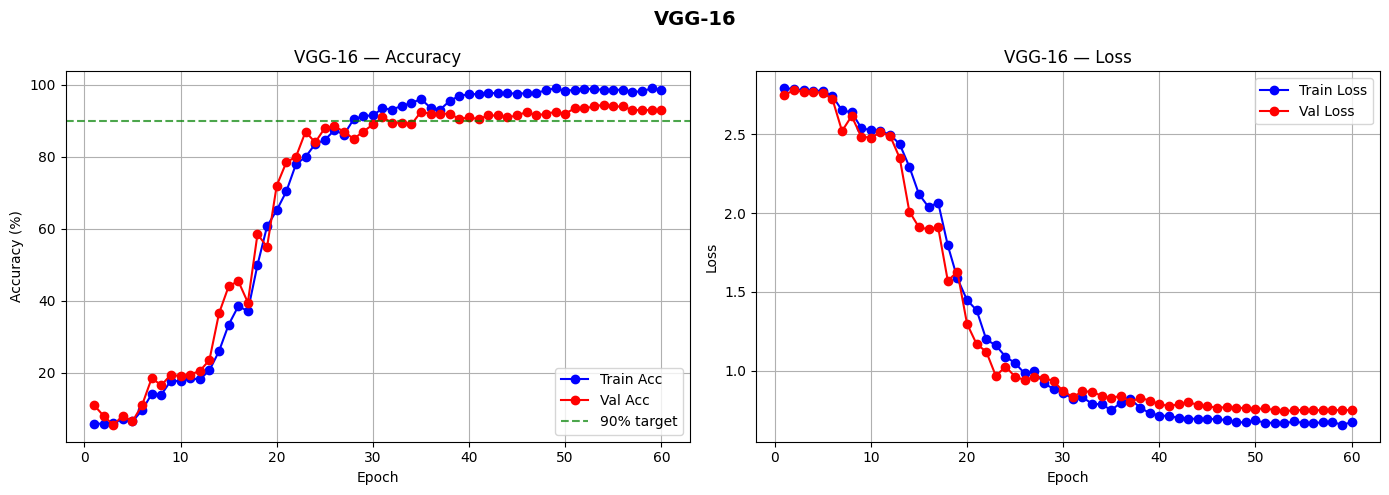

In [25]:
def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history['train_acc']) + 1)

    axes[0].plot(epochs, [a*100 for a in history['train_acc']], 'b-o', label='Train Acc')
    axes[0].plot(epochs, [a*100 for a in history['val_acc']],   'r-o', label='Val Acc')
    axes[0].axhline(y=90, color='green', linestyle='--', alpha=0.7, label='90% target')
    axes[0].set_title(f'{model_name} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy (%)')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
    axes[1].plot(epochs, history['val_loss'],   'r-o', label='Val Loss')
    axes[1].set_title(f'{model_name} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.suptitle(model_name, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/{model_name}_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(vgg_history, 'VGG-16')


## Step 13 — Test Evaluation

In [26]:
def evaluate_model(model, test_loader, class_names, model_name):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f'Testing {model_name}'):
            images   = images.to(device)
            outputs  = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='weighted')

    print(f'Test Results')
    print(f'Overall Accuracy : {acc*100:.2f}%')
    print(f'Weighted F1-Score: {f1:.4f}')
    print(f'\nPer-Class Report:')
    print(classification_report(
        all_labels, all_preds,
        target_names=class_names, digits=4
    ))
    return all_labels, all_preds, acc, f1
v_labels, v_preds, v_acc, v_f1 = evaluate_model(
    vgg_model, test_loader, class_names, 'VGG-16'
)


Testing VGG-16: 100%|██████████| 5/5 [00:01<00:00,  3.72it/s]

Test Results
Overall Accuracy : 92.03%
Weighted F1-Score: 0.9202

Per-Class Report:
                         precision    recall  f1-score   support

 ahmed_sharif_chaudhary     1.0000    1.0000    1.0000         9
           aitzaz_ahsan     0.8000    1.0000    0.8889         8
       asif_ali_zardari     1.0000    0.7778    0.8750         9
             assad_umar     0.8750    0.8750    0.8750         8
 bilawal_bhutto_zardari     1.0000    1.0000    1.0000         8
        chaudhary_nisar     1.0000    0.8750    0.9333         8
chaudhary_pervaiz_elahi     0.8000    1.0000    0.8889         8
             imran_khan     1.0000    0.9091    0.9524        11
              ishaq_dar     0.7273    0.8889    0.8000         9
          khurshid_shah     0.8889    1.0000    0.9412         8
           maryam_nawaz     1.0000    1.0000    1.0000         9
 maulana_fazl-ur-rehman     0.8889    1.0000    0.9412         8
           nawaz_sharif     1.0000    0.8889    0.9412         9
     

## Step 14 — Confusion Matrix

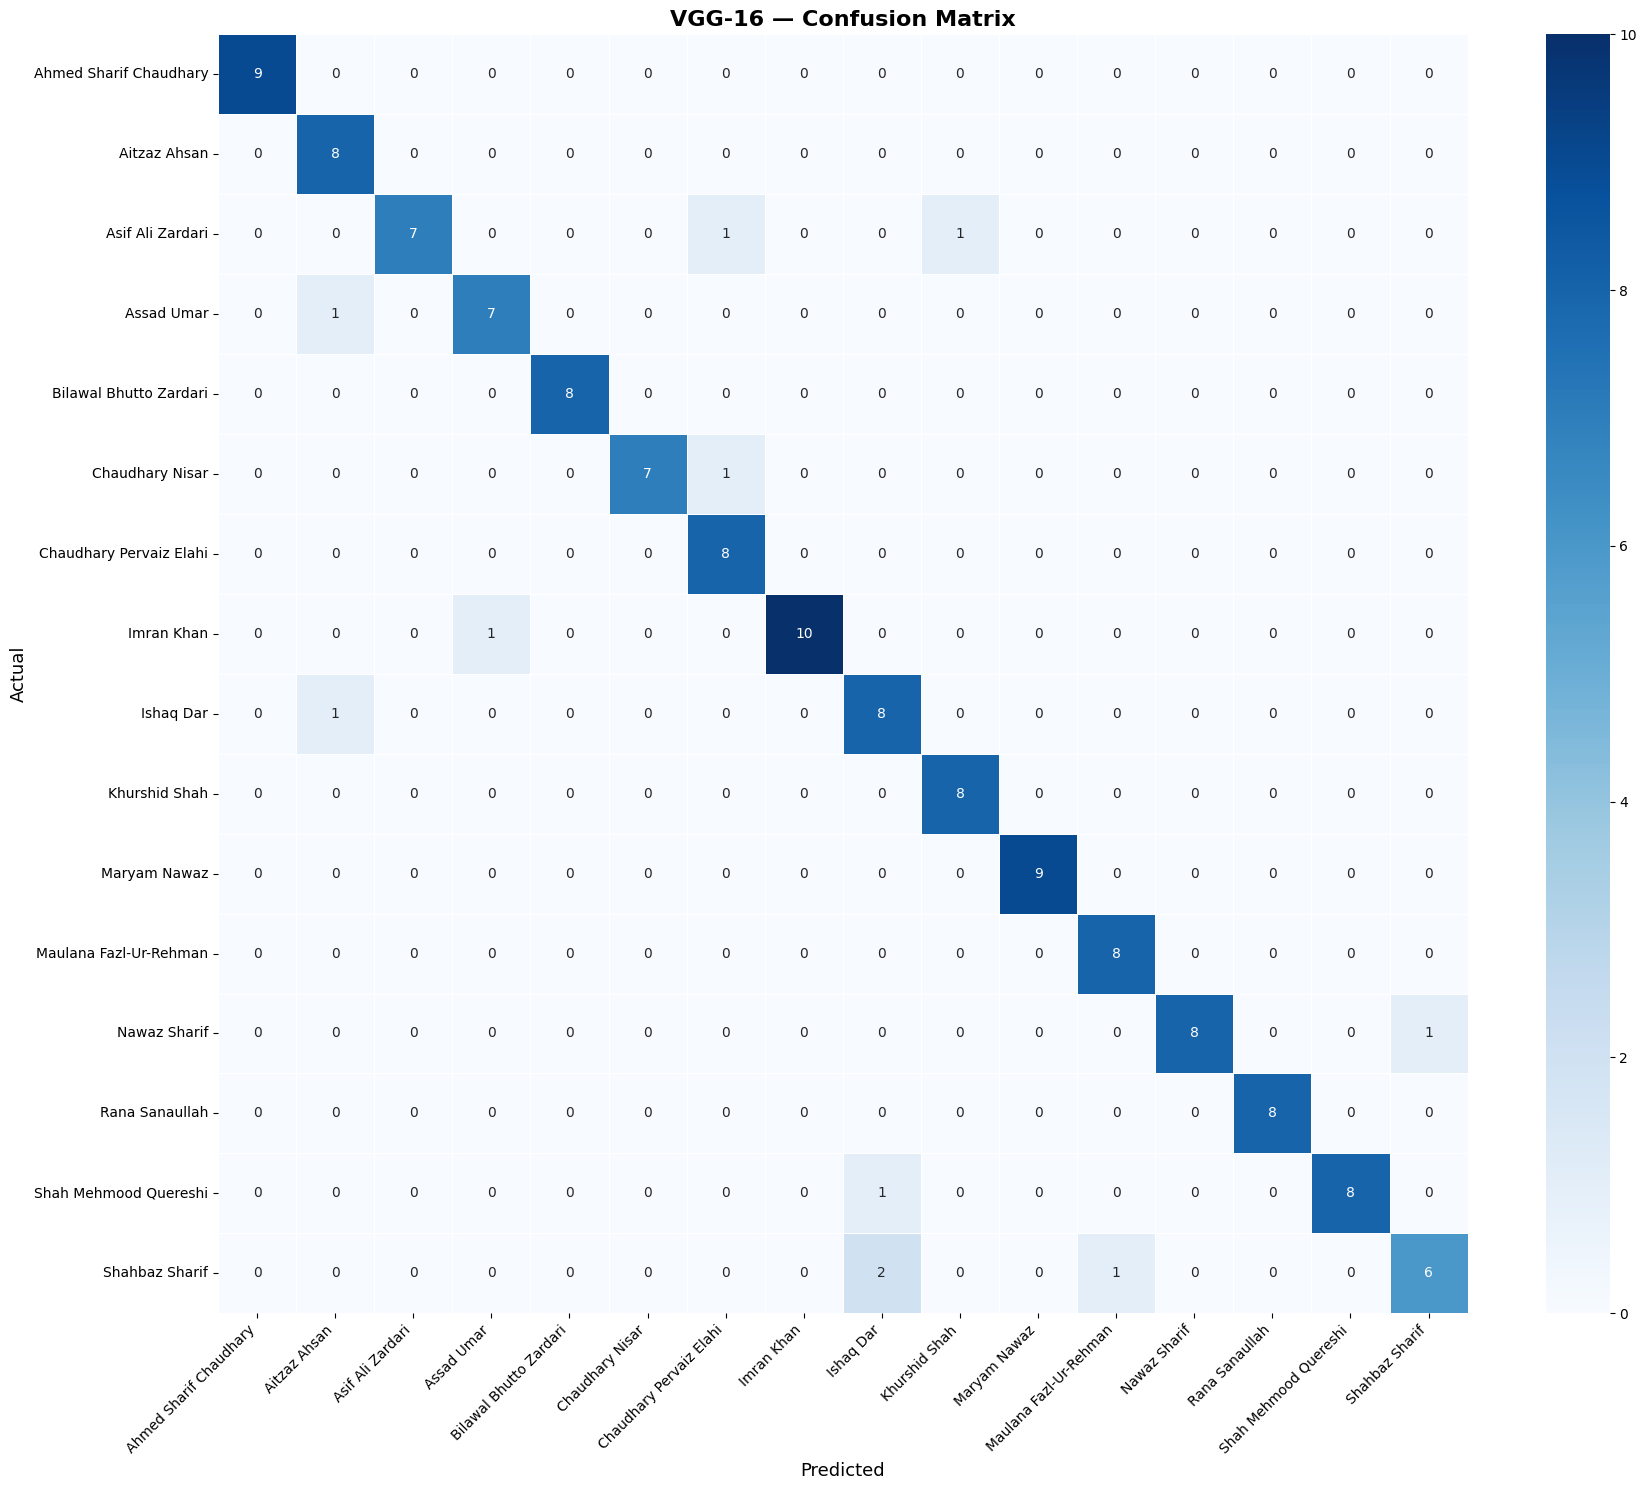

In [27]:
def plot_confusion_matrix(labels, preds, class_names, model_name):
    cm = confusion_matrix(labels, preds)
    pretty_names = [c.replace('_', ' ').title() for c in class_names]
    plt.figure(figsize=(18, 15))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=pretty_names,
                yticklabels=pretty_names,
                linewidths=0.5)
    plt.title(f'{model_name} — Confusion Matrix', fontsize=16, fontweight='bold')
    plt.ylabel('Actual', fontsize=13)
    plt.xlabel('Predicted', fontsize=13)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/{model_name}_confusion_matrix.png',
                dpi=150, bbox_inches='tight')
    plt.show()



plot_confusion_matrix(v_labels, v_preds, class_names, 'VGG-16')


## Step 15 — Top 5 Misclassified

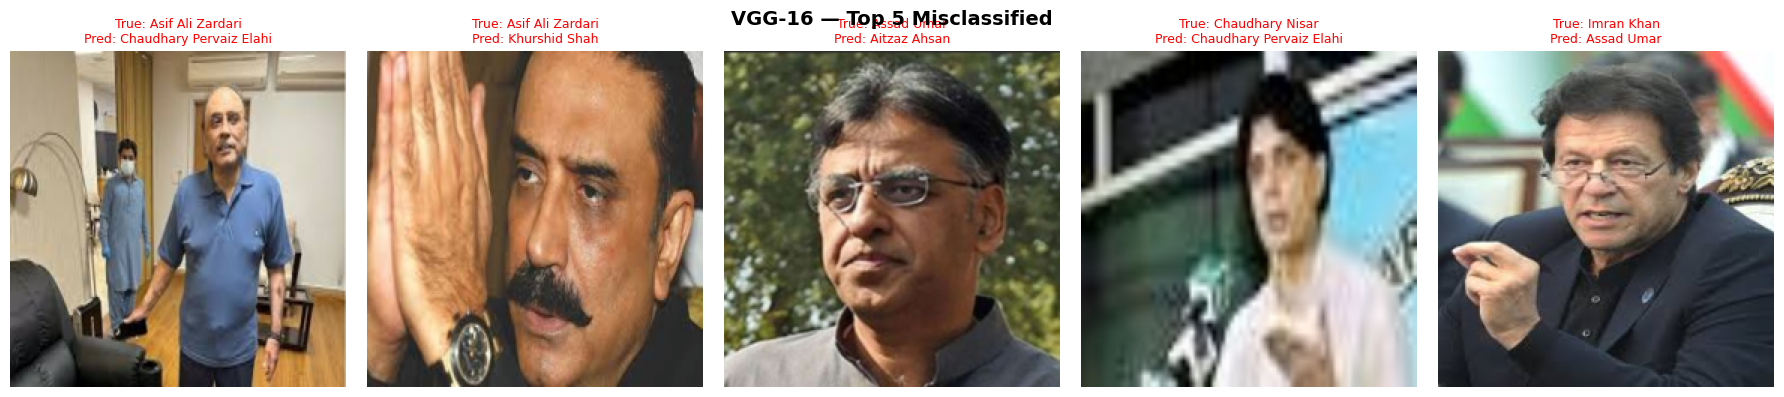

In [28]:
def show_misclassified(model, test_loader, class_names, model_name, top_n=5):
    model.eval()
    misclassified_imgs = []
    misclassified_true = []
    misclassified_pred = []

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    with torch.no_grad():
        for images, labels in test_loader:
            images_dev = images.to(device)
            outputs    = model(images_dev)
            _, preds   = torch.max(outputs, 1)
            preds_cpu  = preds.cpu()

            wrong_idx = (preds_cpu != labels).nonzero(as_tuple=True)[0]
            for idx in wrong_idx:
                if len(misclassified_imgs) >= top_n:
                    break
                img = torch.clamp(images[idx] * std + mean, 0, 1)
                misclassified_imgs.append(img)
                misclassified_true.append(labels[idx].item())
                misclassified_pred.append(preds_cpu[idx].item())
            if len(misclassified_imgs) >= top_n:
                break

    if len(misclassified_imgs) == 0:
        print(' 100% accuracy!')
        return

    fig, axes = plt.subplots(1, min(top_n, len(misclassified_imgs)), figsize=(18, 4))
    if top_n == 1:
        axes = [axes]
    fig.suptitle(f'{model_name} — Top {top_n} Misclassified', fontsize=14, fontweight='bold')
    for i in range(len(misclassified_imgs)):
        axes[i].imshow(misclassified_imgs[i].permute(1, 2, 0))
        true_name = class_names[misclassified_true[i]].replace('_',' ').title()
        pred_name = class_names[misclassified_pred[i]].replace('_',' ').title()
        axes[i].set_title(f'True: {true_name}\nPred: {pred_name}',
                          fontsize=9, color='red')
        axes[i].axis('off')
    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/{model_name}_misclassified.png',
                dpi=150, bbox_inches='tight')
    plt.show()



show_misclassified(vgg_model, test_loader, class_names, 'VGG-16')


In [29]:

vgg_save_path = '/content/drive/MyDrive/VGG16-Final.pth'
torch.save(vgg_model.state_dict(), vgg_save_path)

print(f"VGG-16 model weights saved {vgg_save_path}")


VGG-16 model weights saved /content/drive/MyDrive/VGG16-Final.pth
